# =============================================
# PERTEMUAN 5: Visualisasi Data
## Dashboard Visualisasi Statis
# =============================================

## Import Library

In [60]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

## Load & Inspect Dataset

In [61]:
df = sns.load_dataset('penguins') # menggunakan dataset Penguins
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Pada dataset Pinguins, terdapat missing value pada beberapa kolom yang akan digunakan untuk visualisasi data. Oleh sebab itu, sangat disarankan untuk dibersihkan.

In [62]:
# Menghapus missing value
df = df.dropna()

Missing value telah dihapus dan siap untuk melanjutkan ke tahapan selanjutnya.

In [63]:
print(df.shape, df.dtypes)
print(df.describe().round(2))

(333, 7) species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


## Set Style Layout

In [64]:
# Set Style
sns.set_style('whitegrid')

## GRAFIK 1: Bar Chart

/tmp/ipykernel_7971/1079099104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


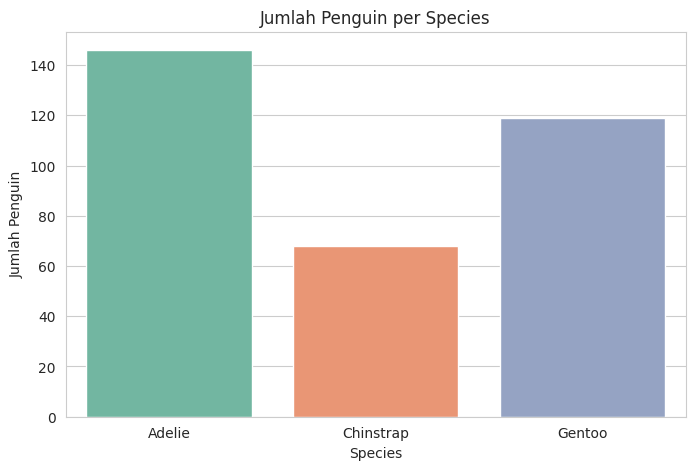

In [65]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='species',
    palette='Set2'
)

plt.title('Jumlah Penguin per Species')
plt.xlabel('Species')
plt.ylabel('Jumlah Penguin')

plt.show()

**(What?)** Grafik bar menunjukkan bahwa species Adelie memiliki jumlah penguin terbanyak, yaitu sekitar 146 data, diikuti Gentoo sebanyak 119 data dan Chinstrap sekitar 68 data.

**(So What?)** Distribusi data yang tidak seimbang menunjukkan bahwa species Adelie mendominasi dataset dengan proporsi hampir dua kali lipat dibanding Chinstrap. Ketidakseimbangan ini dapat mempengaruhi hasil analisis statistik maupun performa model machine learning karena model cenderung lebih mengenali kelas mayoritas.

**(Now What?)** Perlu dilakukan eksplorasi lanjutan untuk memastikan apakah setiap species juga memiliki distribusi fitur fisik yang berbeda secara signifikan, seperti body mass atau flipper length. Jika dataset digunakan untuk klasifikasi, teknik balancing data juga dapat dipertimbangkan.

## GRAFIK 2: Histogram

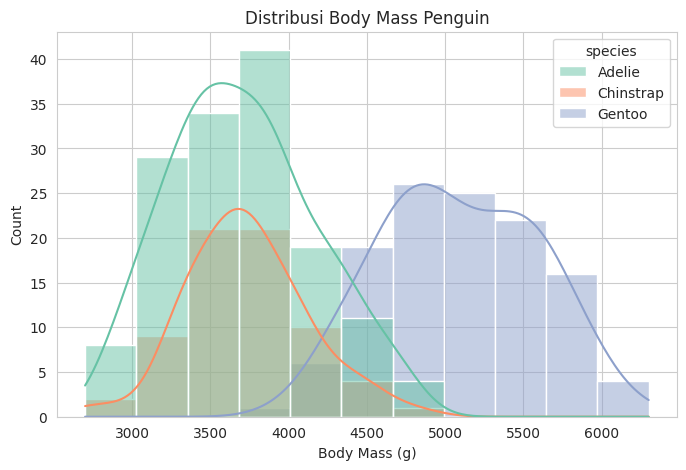

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='body_mass_g',
    hue='species',
    kde=True,
    palette='Set2'
)

plt.title('Distribusi Body Mass Penguin')
plt.xlabel('Body Mass (g)')

plt.show()

**(What?)** Histogram menunjukkan bahwa sebagian besar penguin memiliki body mass pada rentang 3500–5000 gram. Species Gentoo mendominasi area body mass tinggi dengan banyak data berada di atas 5000 gram, sedangkan Adelie terkonsentrasi pada rentang 3000–4000 gram.

**(So What?)** Perbedaan distribusi body mass menunjukkan adanya karakteristik biologis yang berbeda antar species. Body mass tampak menjadi salah satu fitur paling membedakan karena distribusi Gentoo terpisah cukup jelas dari dua species lainnya.

**(Now What?)** Eksplorasi berikutnya dapat melihat hubungan antara body mass dengan flipper length untuk mengetahui apakah penguin yang lebih berat juga memiliki ukuran tubuh lebih besar secara konsisten.

## GRAFIK 3: Boxplot & Violin Plot

/tmp/ipykernel_7971/3554738365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


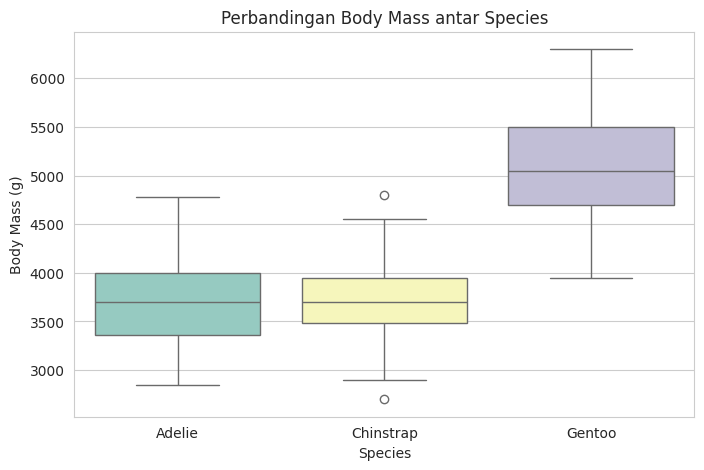

In [67]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='species',
    y='body_mass_g',
    palette='Set3'
)

plt.title('Perbandingan Body Mass antar Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')

plt.show()

**(What?)** Boxplot menunjukkan bahwa Gentoo memiliki median body mass tertinggi sekitar 5000 gram, sedangkan Adelie memiliki median sekitar 3700 gram dan Chinstrap sekitar 3700–3800 gram. Sebaran data Gentoo juga terlihat lebih lebar dibanding species lainnya.

**(So What?)** Perbedaan median body mass yang mencapai lebih dari 1200 gram menunjukkan bahwa ukuran tubuh antar species berbeda secara signifikan. Selain itu, variasi data yang lebih besar pada Gentoo menunjukkan adanya keragaman ukuran tubuh yang lebih tinggi.

**(Now What?)** Perlu dilakukan analisis lebih lanjut untuk mengetahui apakah perbedaan body mass dipengaruhi juga oleh faktor jenis kelamin atau habitat pulau masing-masing species.

/tmp/ipykernel_7971/1525151353.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


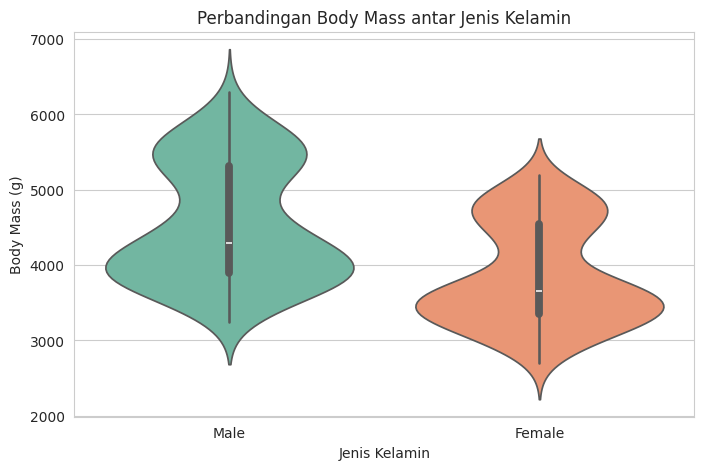

In [68]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x='sex',
    y='body_mass_g',
    palette='Set2'
)

plt.title('Perbandingan Body Mass antar Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Body Mass (g)')

plt.show()

**(What?)** Violin plot menunjukkan bahwa penguin jantan memiliki body mass lebih tinggi dibanding penguin betina. Median body mass jantan berada di sekitar 4000–4500 gram, sedangkan betina cenderung berada di bawah 4000 gram.

**(So What?)** Perbedaan distribusi ini menunjukkan adanya dimorfisme seksual pada penguin, di mana penguin jantan cenderung memiliki ukuran tubuh lebih besar. Sebaran data jantan juga lebih lebar yang menandakan variasi ukuran tubuh lebih tinggi.

**(Now What?)** Eksplorasi berikutnya dapat membandingkan distribusi body mass berdasarkan kombinasi species dan jenis kelamin untuk melihat apakah pola ini konsisten pada semua species penguin.

## GRAFIK 4: Scatter Plot

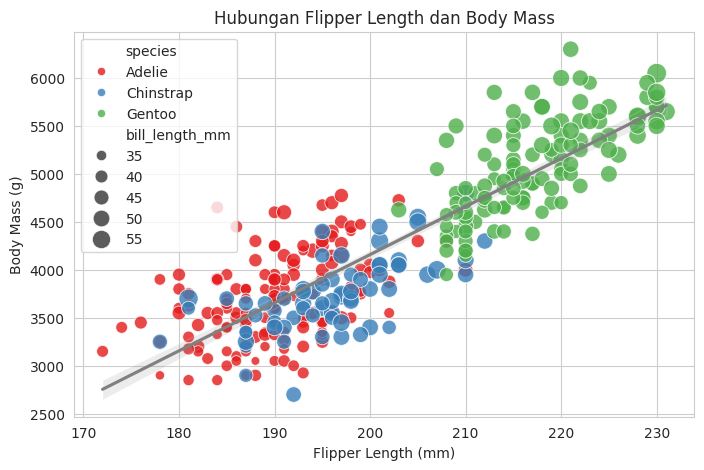

In [69]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    size='bill_length_mm',
    sizes=(40,200),
    palette='Set1',
    alpha=0.8
)

sns.regplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    scatter=False,
    color='gray'
)

plt.title('Hubungan Flipper Length dan Body Mass')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')

plt.show()

**(What?)** Scatter plot menunjukkan hubungan positif antara flipper length dan body mass. Penguin dengan flipper length di atas 220 mm umumnya memiliki body mass lebih dari 5000 gram dan sebagian besar berasal dari species Gentoo.

**(So What?)** Hubungan positif ini menunjukkan bahwa penguin dengan ukuran tubuh lebih besar cenderung memiliki sirip yang lebih panjang. Cluster antar species juga terlihat cukup jelas, sehingga kedua variabel ini berpotensi menjadi fitur penting untuk klasifikasi species.

**(Now What?)** Analisis selanjutnya dapat menggunakan heatmap korelasi atau
pairplot untuk melihat hubungan antar seluruh variabel numerik serta
mengukur kekuatan korelasi secara statistik.

## Ekspor & Show Dashboard

/tmp/ipykernel_7971/96544347.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_7971/96544347.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_7971/96544347.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


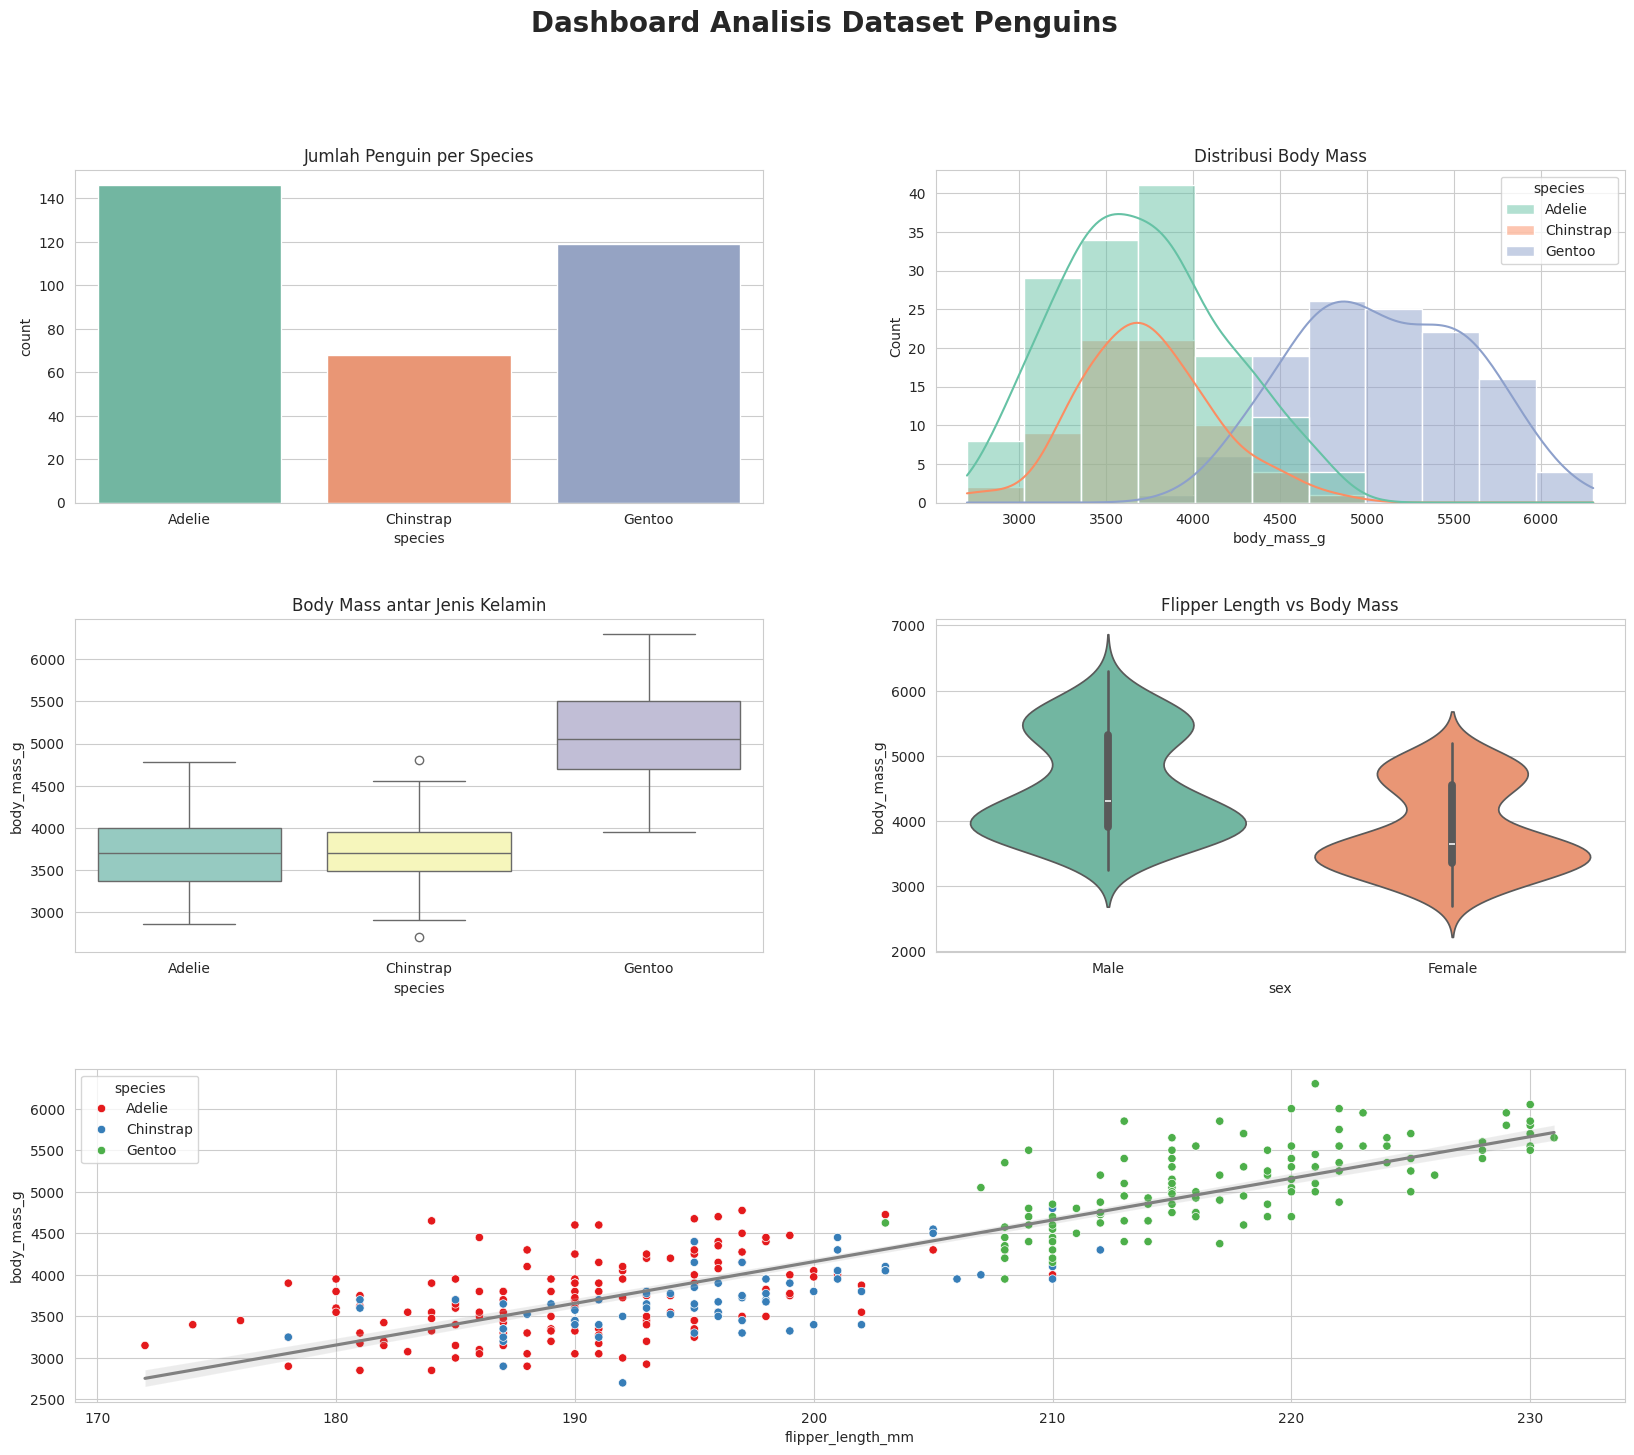

In [70]:
fig = plt.figure(figsize=(20,16))

fig.suptitle(
    'Dashboard Analisis Dataset Penguins',
    fontsize=20,
    fontweight='bold'
)

gs = gridspec.GridSpec(
    3, 2,
    figure=fig,
    hspace=0.35,
    wspace=0.25
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
ax5 = fig.add_subplot(gs[2,:])

# Bar Chart
sns.countplot(
    data=df,
    x='species',
    palette='Set2',
    ax=ax1
)

ax1.set_title('Jumlah Penguin per Species')

# Histogram
sns.histplot(
    data=df,
    x='body_mass_g',
    hue='species',
    kde=True,
    palette='Set2',
    ax=ax2
)

ax2.set_title('Distribusi Body Mass')

# Boxplot
sns.boxplot(
    data=df,
    x='species',
    y='body_mass_g',
    palette='Set3',
    ax=ax3
)

ax3.set_title('Body Mass antar Species')

# Violin Plot
sns.violinplot(
    data=df,
    x='sex',
    y='body_mass_g',
    palette='Set2',
    ax=ax4
)

ax3.set_title('Body Mass antar Jenis Kelamin')

# Scatter Plot
sns.scatterplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    hue='species',
    palette='Set1',
    ax=ax5
)

sns.regplot(
    data=df,
    x='flipper_length_mm',
    y='body_mass_g',
    scatter=False,
    color='gray',
    ax=ax5
)

ax4.set_title('Flipper Length vs Body Mass')

plt.savefig(
    'dashboard_penguins.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

Berdasarkan hasil visualisasi dataset penguins, terlihat bahwa setiap species penguin memiliki karakteristik fisik yang berbeda. Grafik bar chart menunjukkan bahwa species Adelie merupakan species dengan jumlah data terbanyak sekitar 146 penguin, sedangkan Chinstrap memiliki jumlah paling sedikit sekitar 68 penguin. Hal ini menunjukkan distribusi data yang tidak seimbang sehingga perlu diperhatikan pada analisis lanjutan maupun proses machine learning.

Histogram dan boxplot menunjukkan bahwa body mass menjadi salah satu fitur pembeda paling jelas antar species. Species Gentoo memiliki body mass paling besar dengan median sekitar 5000 gram, sedangkan Adelie dan Chinstrap berada pada kisaran 3500–4000 gram. Selain itu, violin plot menunjukkan bahwa penguin jantan cenderung memiliki body mass lebih tinggi dibanding betina, yang menandakan adanya perbedaan ukuran tubuh berdasarkan jenis kelamin.

Scatter plot memperlihatkan hubungan positif antara flipper length dan body mass. Penguin dengan flipper length lebih panjang umumnya memiliki body mass lebih besar, terutama pada species Gentoo yang mendominasi area kanan atas grafik. Pola cluster antar species juga terlihat cukup jelas sehingga fitur body mass dan flipper length berpotensi menjadi variabel penting dalam klasifikasi species penguin.

Sehingga secara keseluruhan, visualisasi data telah menunjukkan pola distribusi, perbedaan karakteristik antar species, serta hubungan antar variabel numerik pada dataset penguins. Analisis lanjutan dapat dilakukan menggunakan heatmap korelasi, pairplot, hingga metode machine learning untuk mempelajari klasifikasi species penguin secara lebih mendalam.
